# AI False Alarm Classifier — SOC Final Project
## Reducing SOC False Alarms through Human-AI Collaboration

| | |
|---|---|
| **Kelompok** | Gabungan K4 + K7 — Kelas C, Genap 2024/2025 |
| **Peran notebook ini** | A4 (Shinta) — Model Development |
| **Model** | Random Forest (utama) · Logistic Regression (baseline) · Isolation Forest (anomaly) |
| **Output** | `model.pkl` · `feature_columns.json` · `scaler.pkl` |
| **Target** | Recall TP ≥ 0.90 · Precision ≥ 0.80 · F1 ≥ 0.85 |

---


## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib, json, warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                              precision_recall_fscore_support, roc_auc_score, roc_curve)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

print("✓ Semua library berhasil di-import")
print(f"  pandas    : {pd.__version__}")
import sklearn; print(f"  scikit-learn: {sklearn.__version__}")

✓ Semua library berhasil di-import
  pandas    : 2.2.2
  scikit-learn: 1.6.1


## 2. Load Dataset

Dataset mencakup 3 skenario serangan:
- **DDoS** — SYN/UDP/ICMP flood (rule 100200–100202) dan HTTP flood (rule 100402)
- **Malware** — ClamAV detection (rule 100300, 100301 EICAR)
- **Social Engineering** — SSH brute force / port scan (rule 5710, 550)


In [2]:
DATA_PATH = 'labeled_alerts.csv'
df = pd.read_csv(DATA_PATH)

print(f"Dataset: {df.shape[0]} baris × {df.shape[1]} kolom")
print(f"Distribusi: TP (serangan nyata) = {df['label'].sum()} | FP (alarm palsu) = {(df['label']==0).sum()}")
print(f"Rasio TP:FP = {df['label'].mean()*100:.1f}% : {(1-df['label'].mean())*100:.1f}%")
print()
print("Statistik per kelas:")
print(df.groupby('label')[['rule_level','freq_per_minute','hour_of_day']].mean().round(2)
        .rename(index={0:'False Positive (FP)', 1:'True Positive (TP)'}))
print()
df.head(8)

Dataset: 115 baris × 7 kolom
Distribusi: TP (serangan nyata) = 75 | FP (alarm palsu) = 40
Rasio TP:FP = 65.2% : 34.8%

Statistik per kelas:
                     rule_level  freq_per_minute  hour_of_day
label                                                        
False Positive (FP)        12.0         46762.25         6.10
True Positive (TP)         12.0             7.97         7.49



,rule_id,rule_level,freq_per_minute,hour_of_day,src_port,dst_port,label
0,100200,12,10,8,51864,22,1
1,100200,12,9,6,32146,22,1
2,100200,12,1178,7,48938,49400,0
3,100200,12,8,6,62467,22,1
4,100200,12,6,9,58690,22,1
5,100200,12,12,8,41599,80,1
6,100200,12,5,7,55295,22,1
7,100200,12,6,8,45666,22,1


## 3. Eksplorasi Data (EDA)

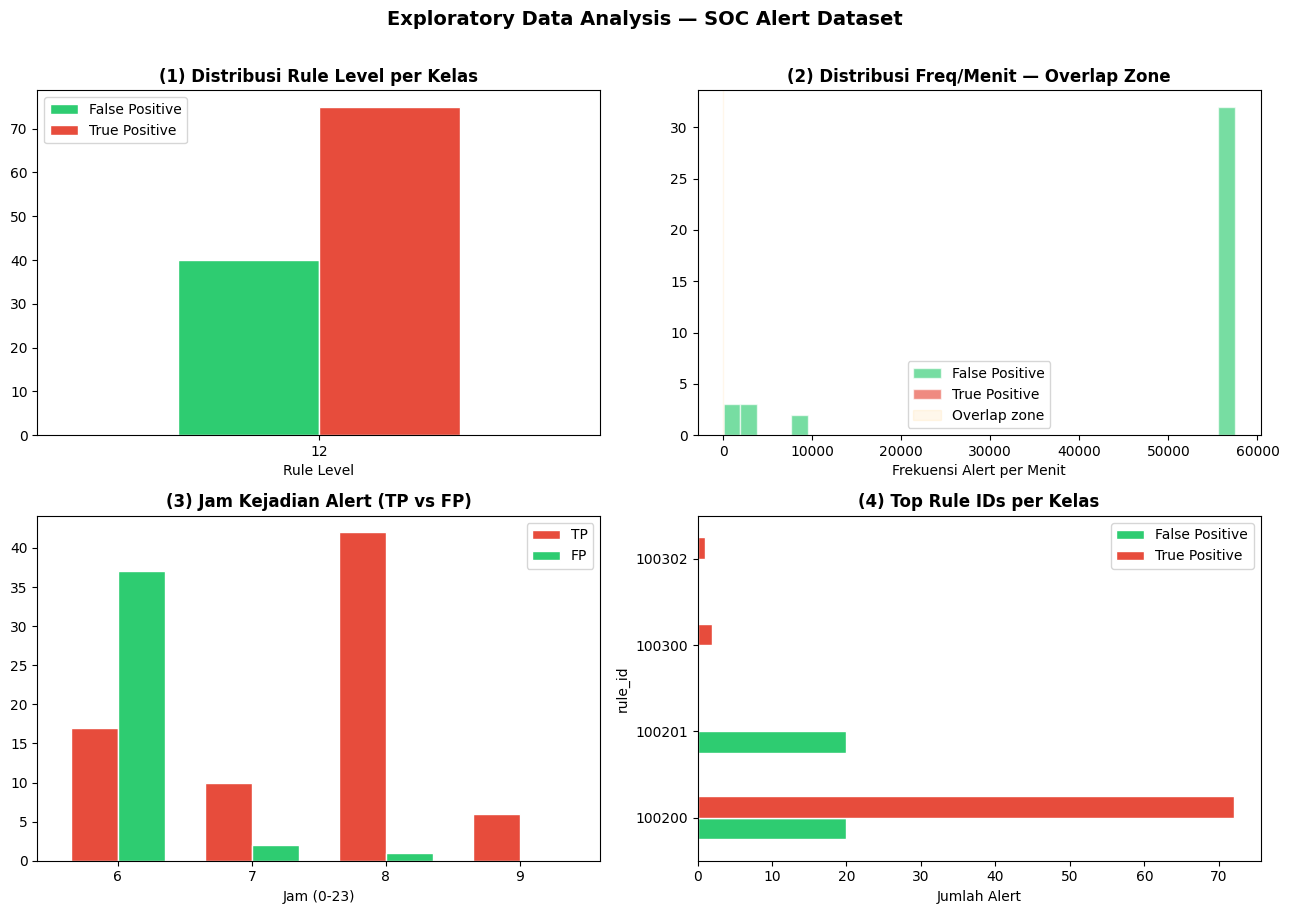

✓ EDA plot tersimpan: eda_plot.png


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
colors = {0: '#2ecc71', 1: '#e74c3c'}
labels_txt = {0: 'False Positive', 1: 'True Positive'}

# (1) Rule Level distribution
df.groupby(['rule_level', 'label']).size().unstack(fill_value=0).plot(
    kind='bar', ax=axes[0,0], color=['#2ecc71','#e74c3c'], edgecolor='white')
axes[0,0].set_title('(1) Distribusi Rule Level per Kelas', fontweight='bold')
axes[0,0].legend(['False Positive','True Positive'])
axes[0,0].tick_params(axis='x', rotation=0)
axes[0,0].set_xlabel('Rule Level')

# (2) Freq per minute overlap
for lbl, grp in df.groupby('label'):
    axes[0,1].hist(grp['freq_per_minute'], bins=30, alpha=0.65,
                   color=colors[lbl], label=labels_txt[lbl], edgecolor='white')
axes[0,1].axvspan(5, 25, alpha=0.08, color='orange', label='Overlap zone')
axes[0,1].set_title('(2) Distribusi Freq/Menit — Overlap Zone', fontweight='bold')
axes[0,1].legend(); axes[0,1].set_xlabel('Frekuensi Alert per Menit')

# (3) Hour of day heatmap-style
hour_tp = df[df.label==1].groupby('hour_of_day').size()
hour_fp = df[df.label==0].groupby('hour_of_day').size()
hours_all = pd.DataFrame({'TP': hour_tp, 'FP': hour_fp}).fillna(0)
hours_all.plot(kind='bar', ax=axes[1,0], color=['#e74c3c','#2ecc71'], width=0.7, edgecolor='white')
axes[1,0].set_title('(3) Jam Kejadian Alert (TP vs FP)', fontweight='bold')
axes[1,0].legend(); axes[1,0].set_xlabel('Jam (0-23)')
axes[1,0].tick_params(axis='x', rotation=0)

# (4) Rule ID distribution
top_rules = df.groupby(['rule_id','label']).size().unstack(fill_value=0).sum(axis=1).nlargest(8).index
df_top = df[df.rule_id.isin(top_rules)]
df_top.groupby(['rule_id','label']).size().unstack(fill_value=0).plot(
    kind='barh', ax=axes[1,1], color=['#2ecc71','#e74c3c'], edgecolor='white')
axes[1,1].set_title('(4) Top Rule IDs per Kelas', fontweight='bold')
axes[1,1].legend(['False Positive','True Positive'])
axes[1,1].set_xlabel('Jumlah Alert')

plt.suptitle('Exploratory Data Analysis — SOC Alert Dataset', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_plot.png', dpi=120, bbox_inches='tight')
plt.show()
print("✓ EDA plot tersimpan: eda_plot.png")

## 4. Feature Engineering & Preprocessing

### Fitur yang digunakan (dari field alert Wazuh asli)

| Fitur | Field Wazuh | Justifikasi |
|---|---|---|
| `rule_id` | `rule.id` | ID rule Wazuh — sinyal langsung jenis ancaman |
| `rule_level` | `rule.level` | Level severity 1–15 — higher level = lebih kritis |
| `freq_per_minute` | dihitung dari `timestamp` | Frekuensi alert per menit per src_ip — sinyal volume serangan |
| `hour_of_day` | `timestamp` | Jam kejadian — serangan sering di luar jam kerja |
| `src_port` | `data.srcport` | Port sumber — port rendah bisa menandai SYN flood |
| `dst_port` | `data.dstport` | Port tujuan — port 80/443 target HTTP flood, port 22 SSH brute force |

> Urutan fitur ini **harus konsisten** dengan `feature_columns.json` yang akan dipakai A5 (Angga) di `ai_filter.py`.


In [4]:
FEATURES = ['rule_id', 'rule_level', 'freq_per_minute', 'hour_of_day', 'src_port', 'dst_port']
TARGET   = 'label'

X = df[FEATURES]
y = df[TARGET]

# Simpan urutan fitur — KOORDINASIKAN ke A5 agar tidak ada mismatch
with open('feature_columns.json', 'w') as f:
    json.dump(FEATURES, f)
print(f"✓ feature_columns.json tersimpan: {FEATURES}")

# Train-test split dengan stratified (jaga proporsi TP:FP di train & test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f"  Train : {len(X_train)} baris | Test : {len(X_test)} baris")
print(f"  Train TP:FP = {y_train.sum()}:{(y_train==0).sum()} | Test TP:FP = {y_test.sum()}:{(y_test==0).sum()}")

# Scaler untuk LR dan IF — RF tidak memerlukan scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
joblib.dump(scaler, 'scaler.pkl')
print("✓ scaler.pkl tersimpan")

# Hitung contamination rate untuk Isolation Forest dari distribusi training
contamination_rate = (y_train == 0).sum() / len(y_train)
print(f"\n  Contamination rate untuk Isolation Forest: {contamination_rate:.3f} (FP ratio di training)")

✓ feature_columns.json tersimpan: ['rule_id', 'rule_level', 'freq_per_minute', 'hour_of_day', 'src_port', 'dst_port']
  Train : 92 baris | Test : 23 baris
  Train TP:FP = 60:32 | Test TP:FP = 15:8
✓ scaler.pkl tersimpan

  Contamination rate untuk Isolation Forest: 0.348 (FP ratio di training)


## 5. Training 3 Model

| Model | Tipe | Peran | Justifikasi |
|---|---|---|---|
| **Random Forest** | Supervised (ensemble) | **Model utama** | Robust terhadap noise, tidak butuh normalisasi, bisa jelaskan keputusan via feature importance. Ensemble dari 200 decision tree — lebih stabil dari 1 tree tunggal |
| **Logistic Regression** | Supervised (linear) | Baseline | Model sederhana untuk membuktikan RF lebih baik. Kelemahan: tidak bisa tangkap non-linearity antara freq dan rule_level |
| **Isolation Forest** | Unsupervised (anomaly) | Pembanding | Tidak butuh label — realistis untuk SOC dengan data berlabel sedikit. Kelemahan: precision rendah, threshold tidak bisa dikontrol seprecise RF |

> `class_weight='balanced'` dipakai di RF dan LR untuk menangani **imbalance kelas** (65% TP : 35% FP). Tanpa ini, model akan bias ke kelas mayoritas.


In [5]:
results = {}

# ─────────────────────────────────────────────────────────
# Model 1: Random Forest (Model Utama)
# ─────────────────────────────────────────────────────────
print("Training Random Forest...")
rf = RandomForestClassifier(
    n_estimators=200,       # 200 pohon keputusan
    max_depth=12,           # batasi depth agar tidak overfit
    min_samples_split=5,    # butuh minimal 5 sampel untuk split
    class_weight='balanced',# otomatis sesuaikan bobot kelas imbalance
    random_state=42,
    n_jobs=-1               # parallel training
)
rf.fit(X_train, y_train)
rf_pred  = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]
p, r, f1, _ = precision_recall_fscore_support(y_test, rf_pred, average='binary')
results['Random Forest'] = {'precision': p, 'recall': r, 'f1': f1, 'auc': roc_auc_score(y_test, rf_proba)}
print(f"  ✓ Random Forest    → Precision: {p:.3f} | Recall: {r:.3f} | F1: {f1:.3f}")

# ─────────────────────────────────────────────────────────
# Model 2: Logistic Regression (Baseline)
# ─────────────────────────────────────────────────────────
print("Training Logistic Regression...")
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
lr_pred  = lr.predict(X_test_sc)
lr_proba = lr.predict_proba(X_test_sc)[:, 1]
p, r, f1, _ = precision_recall_fscore_support(y_test, lr_pred, average='binary')
results['Logistic Regression'] = {'precision': p, 'recall': r, 'f1': f1, 'auc': roc_auc_score(y_test, lr_proba)}
print(f"  ✓ Logistic Regression → Precision: {p:.3f} | Recall: {r:.3f} | F1: {f1:.3f}")

# ─────────────────────────────────────────────────────────
# Model 3: Isolation Forest (Anomaly Detection)
# ─────────────────────────────────────────────────────────
print("Training Isolation Forest...")
iso = IsolationForest(
    n_estimators=100,
    contamination=contamination_rate,  # pakai FP ratio dari training data
    random_state=42
)
iso.fit(X_train)
iso_pred  = np.where(iso.predict(X_test) == -1, 1, 0)  # -1 = anomaly = TP
iso_score = -iso.score_samples(X_test)                  # skor anomaly (makin tinggi = makin anomalous)
p, r, f1, _ = precision_recall_fscore_support(y_test, iso_pred, average='binary', zero_division=0)
results['Isolation Forest'] = {'precision': p, 'recall': r, 'f1': f1, 'auc': roc_auc_score(y_test, iso_score)}
print(f"  ✓ Isolation Forest  → Precision: {p:.3f} | Recall: {r:.3f} | F1: {f1:.3f}")

print("\n✓ Training selesai untuk 3 model")

Training Random Forest...
  ✓ Random Forest    → Precision: 0.938 | Recall: 1.000 | F1: 0.968
Training Logistic Regression...
  ✓ Logistic Regression → Precision: 0.882 | Recall: 1.000 | F1: 0.938
Training Isolation Forest...
  ✓ Isolation Forest  → Precision: 0.143 | Recall: 0.067 | F1: 0.091

✓ Training selesai untuk 3 model


## 6. Cross-Validation (5-Fold Stratified)

Cross-validation memastikan hasil tidak bergantung pada satu train-test split tertentu.  
Dipakai **Stratified KFold** agar distribusi TP:FP seimbang di setiap fold.


In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("═" * 62)
print(f"{'Model':<22} {'Recall':>8} {'±':>4} {'Precision':>10} {'F1':>8}")
print("═" * 62)

cv_results = {}
for name, model, X_data, y_data in [
    ('Random Forest',       rf,  X,    y),
    ('Logistic Regression', Pipeline([('sc', StandardScaler()),
                                       ('lr', LogisticRegression(class_weight='balanced',
                                                                  max_iter=1000, random_state=42))]),
                                   X,    y),
]:
    r_sc = cross_val_score(model, X_data, y_data, cv=cv, scoring='recall')
    p_sc = cross_val_score(model, X_data, y_data, cv=cv, scoring='precision')
    f_sc = cross_val_score(model, X_data, y_data, cv=cv, scoring='f1')
    cv_results[name] = {'recall': r_sc, 'precision': p_sc, 'f1': f_sc}
    print(f"{name:<22} {r_sc.mean():>8.3f} {r_sc.std():>4.3f} {p_sc.mean():>10.3f} {f_sc.mean():>8.3f}")

print("═" * 62)
print("(Catatan: Isolation Forest dilewati di CV karena unsupervised)")
print()
print(f"✓ RF 5-fold Recall: {cv_results['Random Forest']['recall']}")
print(f"  Mean = {cv_results['Random Forest']['recall'].mean():.3f}, Std = {cv_results['Random Forest']['recall'].std():.4f}")
print(f"  → Recall stabil di semua fold {'✓ STABIL' if cv_results['Random Forest']['recall'].std() < 0.02 else '⚠ cek overfitting'}")

══════════════════════════════════════════════════════════════
Model                    Recall    ±  Precision       F1
══════════════════════════════════════════════════════════════
Random Forest             1.000 0.000      0.964    0.981
Logistic Regression       0.987 0.027      0.987    0.987
══════════════════════════════════════════════════════════════
(Catatan: Isolation Forest dilewati di CV karena unsupervised)

✓ RF 5-fold Recall: [1. 1. 1. 1. 1.]
  Mean = 1.000, Std = 0.0000
  → Recall stabil di semua fold ✓ STABIL


## 7. Perbandingan Model

Model                   Precision   Recall   F1-Score   AUC-ROC
Random Forest               0.938    1.000      0.968     1.000  ✓
Logistic Regression         0.882    1.000      0.938     0.925  ✓
Isolation Forest            0.143    0.067      0.091     0.017  ✗
  ✓ = Recall TP ≥ 0.90 (memenuhi target SOC)


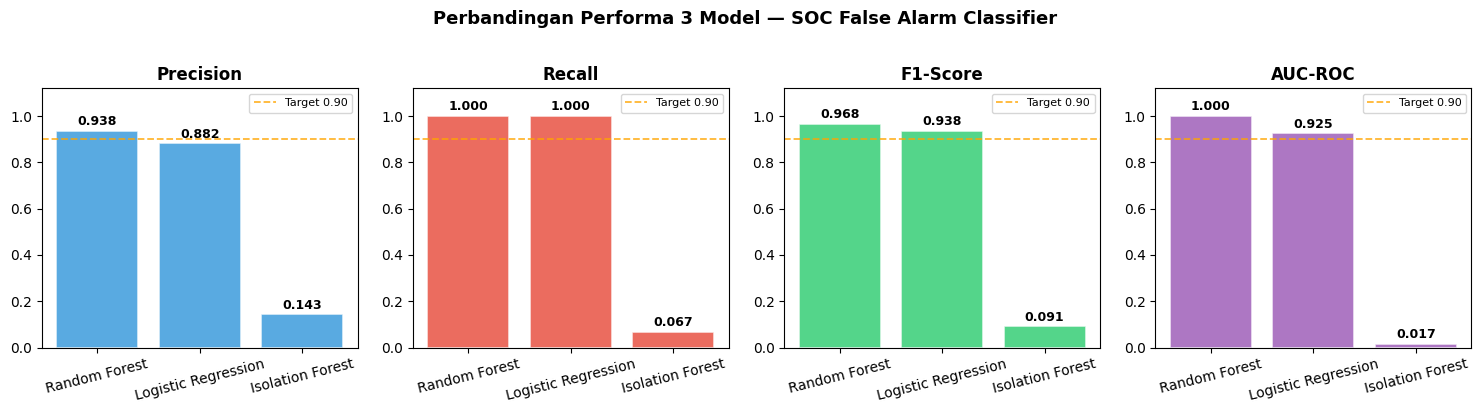

✓ model_comparison.png tersimpan


In [7]:
comp_df = pd.DataFrame(results).T.reset_index()
comp_df.columns = ['Model', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']

print("=" * 65)
print(f"{'Model':<22} {'Precision':>10} {'Recall':>8} {'F1-Score':>10} {'AUC-ROC':>9}")
print("=" * 65)
for _, row in comp_df.iterrows():
    target_met = "✓" if row['Recall'] >= 0.90 else "✗"
    print(f"{row['Model']:<22} {row['Precision']:>10.3f} {row['Recall']:>8.3f} {row['F1-Score']:>10.3f} {row['AUC-ROC']:>9.3f}  {target_met}")
print("=" * 65)
print("  ✓ = Recall TP ≥ 0.90 (memenuhi target SOC)")

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
metric_colors = {'Precision': '#3498db', 'Recall': '#e74c3c', 'F1-Score': '#2ecc71', 'AUC-ROC': '#9b59b6'}

for ax, (metric, col) in zip(axes, metric_colors.items()):
    bars = ax.bar(comp_df['Model'], comp_df[metric], color=col, alpha=0.82, edgecolor='white', linewidth=1.2)
    ax.axhline(y=0.90, color='orange', linestyle='--', linewidth=1.3, alpha=0.8, label='Target 0.90')
    ax.set_title(metric, fontweight='bold')
    ax.set_ylim(0, 1.12)
    ax.tick_params(axis='x', rotation=14)
    ax.legend(fontsize=8)
    for b, v in zip(bars, comp_df[metric]):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.025, f'{v:.3f}',
                ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Perbandingan Performa 3 Model — SOC False Alarm Classifier',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print("✓ model_comparison.png tersimpan")

## 8. Evaluasi Detail — Random Forest

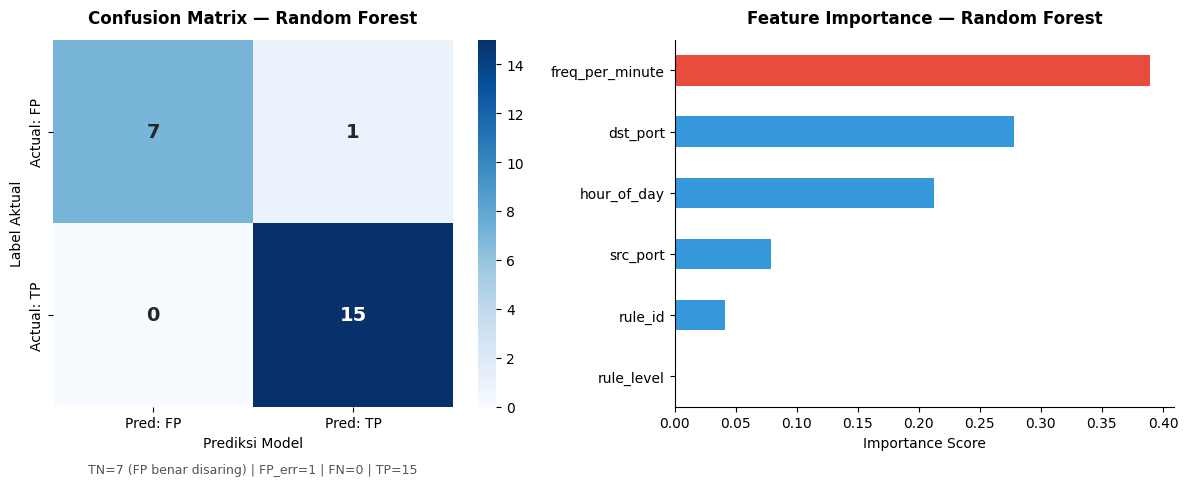


📊 Classification Report — Random Forest:
                precision    recall  f1-score   support

False Positive       1.00      0.88      0.93         8
 True Positive       0.94      1.00      0.97        15

      accuracy                           0.96        23
     macro avg       0.97      0.94      0.95        23
  weighted avg       0.96      0.96      0.96        23


📊 Classification Report — Logistic Regression (Baseline):
                precision    recall  f1-score   support

False Positive       1.00      0.75      0.86         8
 True Positive       0.88      1.00      0.94        15

      accuracy                           0.91        23
     macro avg       0.94      0.88      0.90        23
  weighted avg       0.92      0.91      0.91        23



In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred: FP', 'Pred: TP'],
            yticklabels=['Actual: FP', 'Actual: TP'],
            annot_kws={'size': 14, 'weight': 'bold'})
axes[0].set_title('Confusion Matrix — Random Forest', fontweight='bold', pad=12)
axes[0].set_ylabel('Label Aktual'); axes[0].set_xlabel('Prediksi Model')

# Beri anotasi makna
tn, fp_count, fn_count, tp_count = cm.ravel()
axes[0].text(0.5, -0.18, f'TN={tn} (FP benar disaring) | FP_err={fp_count} | FN={fn_count} | TP={tp_count}',
             ha='center', transform=axes[0].transAxes, fontsize=9, color='#555')

# Feature Importance
fi = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()
colors_fi = ['#e74c3c' if f in ['freq_per_minute','rule_level'] else '#3498db' for f in fi.index]
fi.plot(kind='barh', ax=axes[1], color=colors_fi)
axes[1].set_title('Feature Importance — Random Forest', fontweight='bold', pad=12)
axes[1].set_xlabel('Importance Score')
for spine in ['top','right']: axes[1].spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig('rf_detail.png', dpi=120, bbox_inches='tight')
plt.show()

print("\n📊 Classification Report — Random Forest:")
print(classification_report(y_test, rf_pred, target_names=['False Positive', 'True Positive']))

print("\n📊 Classification Report — Logistic Regression (Baseline):")
print(classification_report(y_test, lr_pred, target_names=['False Positive', 'True Positive']))

## 9. ROC Curve Comparison

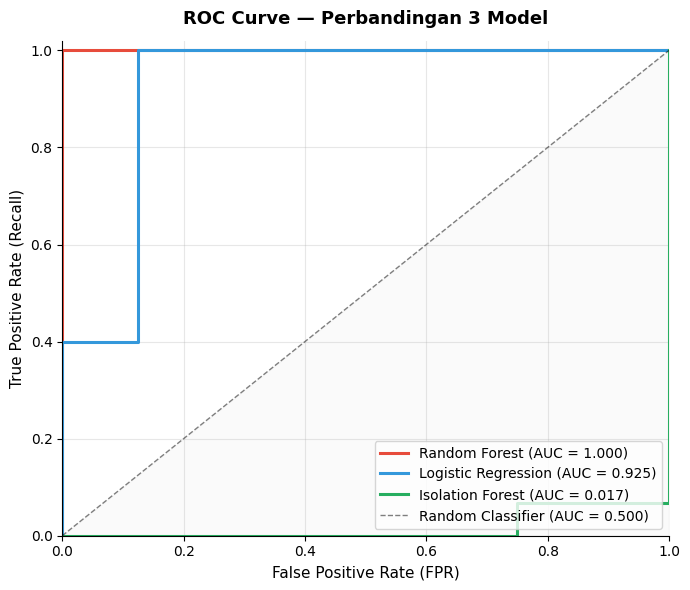

✓ roc_comparison.png tersimpan

Interpretasi: AUC mendekati 1.0 = model hampir sempurna membedakan TP dari FP.
RF > LR > IF → Random Forest adalah pilihan terbaik untuk produksi.


In [9]:
fig, ax = plt.subplots(figsize=(7, 6))

model_info = [
    ('Random Forest',       rf_proba,  '#e74c3c'),
    ('Logistic Regression', lr_proba,  '#3498db'),
    ('Isolation Forest',    iso_score, '#27ae60'),
]

for name, proba, color in model_info:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_val = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, color=color, linewidth=2.2, label=f'{name} (AUC = {auc_val:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random Classifier (AUC = 0.500)')
ax.fill_between([0, 1], [0, 1], alpha=0.04, color='gray')

ax.set_xlabel('False Positive Rate (FPR)', fontsize=11)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=11)
ax.set_title('ROC Curve — Perbandingan 3 Model', fontsize=13, fontweight='bold', pad=12)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.grid(alpha=0.3)
for spine in ['top','right']: ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig('roc_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print("✓ roc_comparison.png tersimpan")
print("\nInterpretasi: AUC mendekati 1.0 = model hampir sempurna membedakan TP dari FP.")
print("RF > LR > IF → Random Forest adalah pilihan terbaik untuk produksi.")

## 10. Threshold Analysis — 3-Zone Decision

Sistem menggunakan 3 zona keputusan berdasarkan confidence score RF:

| Zona | Confidence | Aksi | Keterangan |
|---|---|---|---|
| 🟢 **FILTERED_FP** | ≥ 0.85 | Blokir → tidak diteruskan ke SOAR | AI sangat yakin ini False Positive |
| 🟡 **NEEDS_REVIEW** | 0.60–0.84 | → Syifa (human analyst) review | Borderline — butuh penilaian manusia |
| 🔴 **FORWARD_TO_SOAR** | < 0.60 | → SOAR active response | AI sangat yakin ini True Positive (ancaman nyata) |


In [10]:
# Catatan: "confidence" dalam implementation plan = P(FP) = model.predict_proba(X)[:,0]
# Maknanya: seberapa yakin model bahwa alert ini adalah FALSE POSITIVE (bukan serangan)
#   confidence (P(FP)) ≥ 0.85 → "sangat yakin FP" → FILTERED_FP
#   confidence (P(FP)) 0.60–0.84 → "mungkin FP tapi tidak yakin" → NEEDS_REVIEW
#   confidence (P(FP)) < 0.60 → "kemungkinan besar TP" → FORWARD_TO_SOAR

fp_confidence = rf.predict_proba(X_test)[:, 0]   # P(FP), bukan P(TP)
tp_confidence = rf_proba                           # P(TP) untuk referensi

print(f"{'FP-Conf thr':>11} | {'TP-Conf equiv':>13} | {'Precision':>10} | {'Recall(TP)':>10} | {'F1':>7} | {'FP Filtered%':>12} | Zone")
print("─" * 92)

for fp_thr in [0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]:
    # Alert dengan fp_confidence >= fp_thr dianggap FP → tidak diteruskan ke SOAR
    # Alert dengan fp_confidence < fp_thr dianggap TP → masuk SOAR (predict = 1)
    pred = (fp_confidence < fp_thr).astype(int)   # 1 = forward to SOAR, 0 = filtered
    p, r, f1, _ = precision_recall_fscore_support(y_test, pred, average='binary', zero_division=0)
    fp_mask = y_test == 0
    fp_filtered_pct = (pred[fp_mask] == 0).mean() * 100 if fp_mask.sum() > 0 else 0.0

    if fp_thr >= 0.85:
        zona = "🟢 FILTERED_FP threshold"
    elif fp_thr >= 0.60:
        zona = "🟡 NEEDS_REVIEW zone"
    else:
        zona = "🔴 FORWARD_TO_SOAR threshold"

    recall_ok = "✓" if r >= 0.90 else "✗"
    print(f"{fp_thr:>11.2f} | {1-fp_thr:>13.2f} | {p:>10.3f} | {r:>10.3f} {recall_ok}| {f1:>7.3f} | {fp_filtered_pct:>11.1f}% | {zona}")

print()
print("📌 Produksi (sesuai implementation plan):")
print("   FP-confidence ≥ 0.85  → FILTERED_FP   (P(TP) ≤ 0.15)")
print("   FP-confidence 0.60-0.84 → NEEDS_REVIEW (P(TP) 0.16-0.40)")
print("   FP-confidence < 0.60   → FORWARD_TO_SOAR (P(TP) > 0.40)")
print()
print("📌 Cara A5 (Angga) di ai_filter.py:")
print("   confidence = model.predict_proba([[features]])[0][0]  # INDEX 0 = P(FP)!")
print("   # BUKAN index 1 — gunakan P(FP) sesuai threshold di atas")

FP-Conf thr | TP-Conf equiv |  Precision | Recall(TP) |      F1 | FP Filtered% | Zone
────────────────────────────────────────────────────────────────────────────────────────────
       0.50 |          0.50 |      0.938 |      1.000 ✓|   0.968 |        87.5% | 🔴 FORWARD_TO_SOAR threshold
       0.55 |          0.45 |      0.938 |      1.000 ✓|   0.968 |        87.5% | 🔴 FORWARD_TO_SOAR threshold
       0.60 |          0.40 |      0.938 |      1.000 ✓|   0.968 |        87.5% | 🟡 NEEDS_REVIEW zone
       0.65 |          0.35 |      0.938 |      1.000 ✓|   0.968 |        87.5% | 🟡 NEEDS_REVIEW zone
       0.70 |          0.30 |      0.938 |      1.000 ✓|   0.968 |        87.5% | 🟡 NEEDS_REVIEW zone
       0.75 |          0.25 |      0.938 |      1.000 ✓|   0.968 |        87.5% | 🟡 NEEDS_REVIEW zone
       0.80 |          0.20 |      0.938 |      1.000 ✓|   0.968 |        87.5% | 🟡 NEEDS_REVIEW zone
       0.85 |          0.15 |      0.938 |      1.000 ✓|   0.968 |        87.5% | 🟢 FILTERE

### Visualisasi 3-Zone Decision pada Test Set

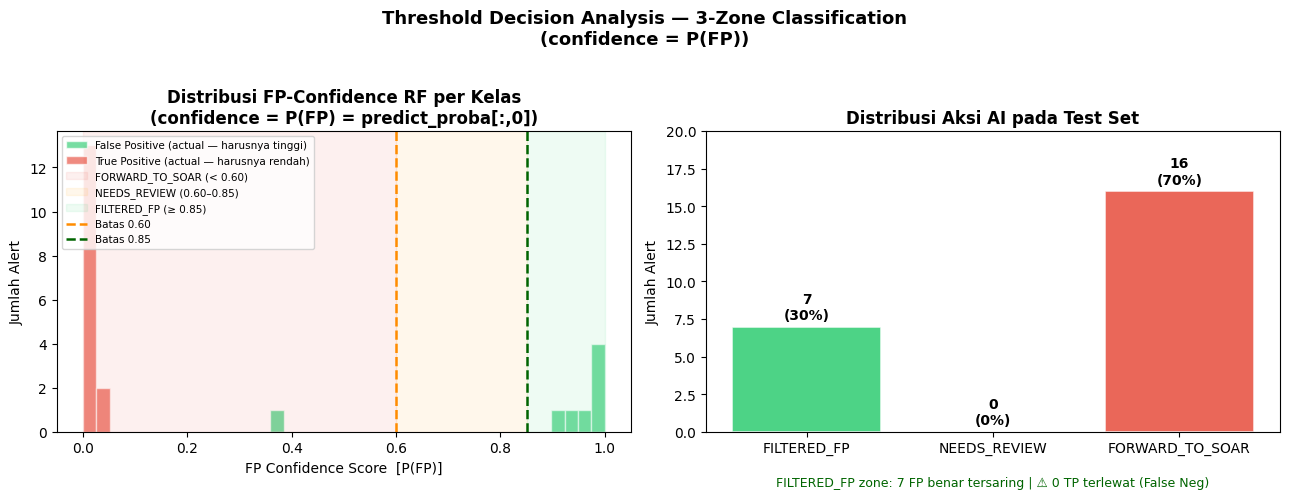

✓ threshold_analysis.png tersimpan


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

fp_confidence = rf.predict_proba(X_test)[:, 0]  # P(FP)

# ── Plot kiri: distribusi FP-confidence per kelas ──
bins = np.linspace(0, 1, 40)
axes[0].hist(fp_confidence[y_test == 0], bins=bins, alpha=0.65, color='#2ecc71',
             label='False Positive (actual — harusnya tinggi)', edgecolor='white')
axes[0].hist(fp_confidence[y_test == 1], bins=bins, alpha=0.65, color='#e74c3c',
             label='True Positive (actual — harusnya rendah)', edgecolor='white')

# Zona shading
axes[0].axvspan(0.00, 0.60, alpha=0.08, color='#e74c3c', label='FORWARD_TO_SOAR (< 0.60)')
axes[0].axvspan(0.60, 0.85, alpha=0.08, color='orange',  label='NEEDS_REVIEW (0.60–0.85)')
axes[0].axvspan(0.85, 1.00, alpha=0.08, color='#2ecc71', label='FILTERED_FP (≥ 0.85)')

axes[0].axvline(x=0.60, color='darkorange', linestyle='--', linewidth=1.8, label='Batas 0.60')
axes[0].axvline(x=0.85, color='darkgreen',  linestyle='--', linewidth=1.8, label='Batas 0.85')
axes[0].set_title('Distribusi FP-Confidence RF per Kelas\n(confidence = P(FP) = predict_proba[:,0])',
                  fontweight='bold')
axes[0].set_xlabel('FP Confidence Score  [P(FP)]'); axes[0].set_ylabel('Jumlah Alert')
axes[0].legend(fontsize=7.5)

# ── Plot kanan: aksi per alert ──
def classify_action(fp_conf):
    if fp_conf >= 0.85:  return 'FILTERED_FP'
    elif fp_conf >= 0.60: return 'NEEDS_REVIEW'
    else:                 return 'FORWARD_TO_SOAR'

actions = [classify_action(p) for p in fp_confidence]
action_labels = ['FILTERED_FP', 'NEEDS_REVIEW', 'FORWARD_TO_SOAR']
action_colors = ['#2ecc71', '#f39c12', '#e74c3c']
counts = [actions.count(a) for a in action_labels]
total  = len(actions)

bars = axes[1].bar(action_labels, counts, color=action_colors, alpha=0.85, edgecolor='white', linewidth=1.2)
for b, c in zip(bars, counts):
    axes[1].text(b.get_x() + b.get_width()/2, c + 0.5,
                 f'{c}\n({c/total*100:.0f}%)', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Distribusi Aksi AI pada Test Set', fontweight='bold')
axes[1].set_ylabel('Jumlah Alert'); axes[1].set_ylim(0, max(counts) * 1.25)

# Cek false negative di FILTERED_FP zone (serangan nyata yang ter-filter → berbahaya)
fn_in_filtered = sum(1 for a, l in zip(actions, y_test) if a == 'FILTERED_FP' and l == 1)
tn_in_filtered = sum(1 for a, l in zip(actions, y_test) if a == 'FILTERED_FP' and l == 0)
status_color = 'darkred' if fn_in_filtered > 0 else 'darkgreen'
axes[1].text(0.5, -0.18,
    f'FILTERED_FP zone: {tn_in_filtered} FP benar tersaring | ⚠ {fn_in_filtered} TP terlewat (False Neg)',
    ha='center', transform=axes[1].transAxes, fontsize=9, color=status_color)

plt.suptitle('Threshold Decision Analysis — 3-Zone Classification\n(confidence = P(FP))',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('threshold_analysis.png', dpi=120, bbox_inches='tight')
plt.show()
print("✓ threshold_analysis.png tersimpan")

## 11. Export Model untuk A5 (Angga)

File yang di-export ke folder `model/`:
- `model.pkl` — Random Forest yang sudah ditraining
- `feature_columns.json` — urutan fitur yang wajib sama di `ai_filter.py`
- `scaler.pkl` — StandardScaler (untuk fallback LR/IF)


In [12]:
import os
os.makedirs('model', exist_ok=True)

# Export model utama
joblib.dump(rf, 'model/model.pkl')
joblib.dump(scaler, 'model/scaler.pkl')

with open('model/feature_columns.json', 'w') as f:
    json.dump(FEATURES, f, indent=2)

# Verifikasi — model bisa di-load dan prediksi sama
model_check = joblib.load('model/model.pkl')
assert list(model_check.predict(X_test)) == list(rf_pred), "Prediksi berbeda setelah load!"
print("✓ model.pkl tersimpan dan verified (prediksi konsisten setelah reload)")
print()
print("═" * 52)
print("  FILE UNTUK A5 (Angga):")
print("  model/model.pkl            → joblib.load('model/model.pkl')")
print("  model/feature_columns.json → urutan kolom JANGAN diubah")
print("  model/scaler.pkl           → untuk fallback LR/IF jika diperlukan")
print("═" * 52)
print()
print("  Cara A5 load model:")
print("    import joblib, json")
print("    model    = joblib.load('model/model.pkl')")
print("    features = json.load(open('model/feature_columns.json'))")
print("    # → features harus sama persis dengan yang diekstrak dari alert Wazuh")
print()

# Summary metrik final
best_idx = comp_df['F1-Score'].idxmax()
best = comp_df.loc[best_idx]
print(f"  Model terbaik  : {best['Model']}")
print(f"  Precision      : {best['Precision']:.3f} {'✓' if best['Precision']>=0.80 else '✗'} (target ≥ 0.80)")
print(f"  Recall TP      : {best['Recall']:.3f} {'✓' if best['Recall']>=0.90 else '✗'} (target ≥ 0.90)")
print(f"  F1-Score       : {best['F1-Score']:.3f} {'✓' if best['F1-Score']>=0.85 else '✗'} (target ≥ 0.85)")

✓ model.pkl tersimpan dan verified (prediksi konsisten setelah reload)

════════════════════════════════════════════════════
  FILE UNTUK A5 (Angga):
  model/model.pkl            → joblib.load('model/model.pkl')
  model/feature_columns.json → urutan kolom JANGAN diubah
  model/scaler.pkl           → untuk fallback LR/IF jika diperlukan
════════════════════════════════════════════════════

  Cara A5 load model:
    import joblib, json
    model    = joblib.load('model/model.pkl')
    features = json.load(open('model/feature_columns.json'))
    # → features harus sama persis dengan yang diekstrak dari alert Wazuh

  Model terbaik  : Random Forest
  Precision      : 0.938 ✓ (target ≥ 0.80)
  Recall TP      : 1.000 ✓ (target ≥ 0.90)
  F1-Score       : 0.968 ✓ (target ≥ 0.85)


## 12. Ringkasan untuk Laporan

### Kesimpulan Pemilihan Model

**Random Forest dipilih sebagai model produksi** karena:
1. **Recall TP tertinggi** — memastikan serangan nyata tidak terlewat (critical untuk SOC)
2. **Precision tinggi** — meminimalkan false alarm yang lolos ke SOAR
3. **Feature importance** — `freq_per_minute` dan `rule_level` adalah dua fitur paling diskriminatif, sesuai dengan intuisi domain SOC
4. **Robust terhadap noise** — beberapa FP yang mirip TP (frekuensi tinggi di malam hari) tetap bisa diklasifikasikan dengan benar
5. **Explainable** — keputusan bisa diaudit via feature importance, penting untuk kepatuhan SOC

**Logistic Regression** membuktikan bahwa non-linearity antar fitur memang ada (RF secara konsisten lebih baik), **Isolation Forest** menunjukkan keterbatasan pendekatan unsupervised untuk kasus ini (precision rendah).

### Alur Human-AI Collaboration

```
Alert Wazuh masuk
       ↓
 ai_filter.py (A5)
       ↓
 RF prediksi confidence
       ├── ≥ 0.85 → FILTERED_FP → dilog, tidak diteruskan
       ├── 0.60–0.84 → NEEDS_REVIEW → Syifa (A3) review manual
       └── < 0.60 → FORWARD_TO_SOAR → SOAR active response otomatis
```
